1️⃣ IMPORT LIBRARIES

In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
import cv2

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report, confusion_matrix

2026-05-17 19:18:37.708995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779045517.892881      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779045517.949716      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779045518.395852      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779045518.395905      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779045518.395908      23 computation_placer.cc:177] computation placer alr

2️⃣ DATASET PATH

In [2]:
BASE_DIR = "/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Train folders:", os.listdir(TRAIN_DIR))
print("Test folders:", os.listdir(TEST_DIR))

Train folders: ['Benign', 'Malignant']
Test folders: ['Benign', 'Malignant']


3️⃣ REMOVE CORRUPT IMAGES

In [3]:
def remove_corrupt_images(folder):

    checked = 0
    removed = 0

    for root, dirs, files in os.walk(folder):

        for file in files:

            path = os.path.join(root, file)

            checked += 1

            try:
                img = Image.open(path)
                img.verify()

            except:

                print("Removing corrupt image:", path)

                os.remove(path)

                removed += 1

    print(f"Checked Images: {checked}")
    print(f"Corrupt Images Removed: {removed}")

4️⃣ REMOVE BLANK IMMAGES

In [4]:
def remove_blank_images(folder):

    for root, dirs, files in os.walk(folder):

        for file in files:

            path = os.path.join(root, file)

            try:
                img = cv2.imread(path)

                if img is None or np.mean(img) < 1:
                    print("Removing blank image:", path)
                    os.remove(path)

            except:
                pass

5️⃣ RUN CLEANING FUNCTIONS

In [5]:
remove_corrupt_images(TRAIN_DIR)
remove_corrupt_images(TEST_DIR)

remove_blank_images(TRAIN_DIR)
remove_blank_images(TEST_DIR)

Checked Images: 11879
Corrupt Images Removed: 0
Checked Images: 2000
Corrupt Images Removed: 0


6️⃣ IMAGE SIZE AND BATCH SIZE

In [6]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

7️⃣ DATA AUGMENTATION

In [7]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=25,

    zoom_range=0.25,

    horizontal_flip=True,

    vertical_flip=True,

    width_shift_range=0.1,

    height_shift_range=0.1,

    brightness_range=[0.8, 1.2],

    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

8️⃣ TRAIN GENERATOR

In [8]:
train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    subset='training'
)

Found 9504 images belonging to 2 classes.


9️⃣ VALIDATION GENERATOR

In [9]:
val_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    subset='validation'
)

Found 2375 images belonging to 2 classes.


🔟 TEST GENERATOR

In [10]:
test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=False
)

print("Class Labels:", train_generator.class_indices)

Found 2000 images belonging to 2 classes.
Class Labels: {'Benign': 0, 'Malignant': 1}


11. DISPLAY SAMPLE IMAGES

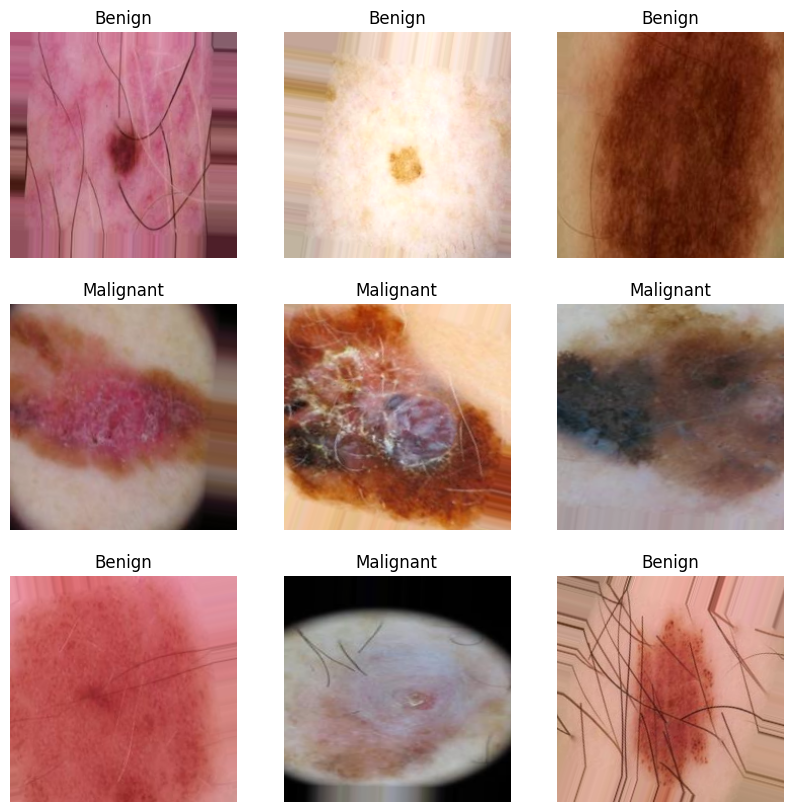

In [11]:
def plot_images(generator):

    images, labels = next(generator)

    plt.figure(figsize=(10,10))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title("Malignant" if labels[i] == 1 else "Benign")

        plt.axis("off")

    plt.show()

plot_images(train_generator)

12. BUILD CNN MODEL

In [12]:
model = models.Sequential([

    # BLOCK 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(224,224,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    # BLOCK 2
    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    # BLOCK 3
    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    # BLOCK 4
    layers.Conv2D(
        256,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    # BETTER THAN FLATTEN
    layers.GlobalAveragePooling2D(),

    # FULLY CONNECTED LAYER
    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    # OUTPUT LAYER
    layers.Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779045664.792467      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


13. COMPILE MODEL

In [13]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

14. MODEL SUMMARY

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

15. CALLBACKS

In [15]:
early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=7,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=1e-7,

    verbose=1
)

16. TRAIN MODEL

In [16]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=30,

    callbacks=[early_stopping, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1779045670.759669      92 service.cc:152] XLA service 0x7ba6d0115c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779045670.759705      92 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779045671.445211      92 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/297 ━━━━━━━━━━━━━━━━━━━━ 50:08 10s/step - accuracy: 0.5000 - loss: 0.8037

I0000 00:00:1779045677.354418      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


297/297 ━━━━━━━━━━━━━━━━━━━━ 157s 494ms/step - accuracy: 0.7688 - loss: 0.5186 - val_accuracy: 0.5436 - val_loss: 0.8835 - learning_rate: 0.0010
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 142s 479ms/step - accuracy: 0.8242 - loss: 0.3908 - val_accuracy: 0.6434 - val_loss: 0.7167 - learning_rate: 0.0010
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 142s 477ms/step - accuracy: 0.8450 - loss: 0.3676 - val_accuracy: 0.6796 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 142s 477ms/step - accuracy: 0.8479 - loss: 0.3574 - val_accuracy: 0.7469 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 141s 474ms/step - accuracy: 0.8490 - loss: 0.3426 - val_accuracy: 0.7937 - val_loss: 0.4752 - learning_rate: 0.0010
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 140s 470ms/step - accuracy: 0.8531 - loss: 0.3437 - val_accuracy: 0.7781 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 138s 465ms/step - accuracy: 0.8604 

17. SAVE MODEL

In [17]:
model.save("skin_cancer_cnn.h5")

print("Model Saved Successfully")

Model Saved Successfully


18. PLOT ACCURACY GRAPH

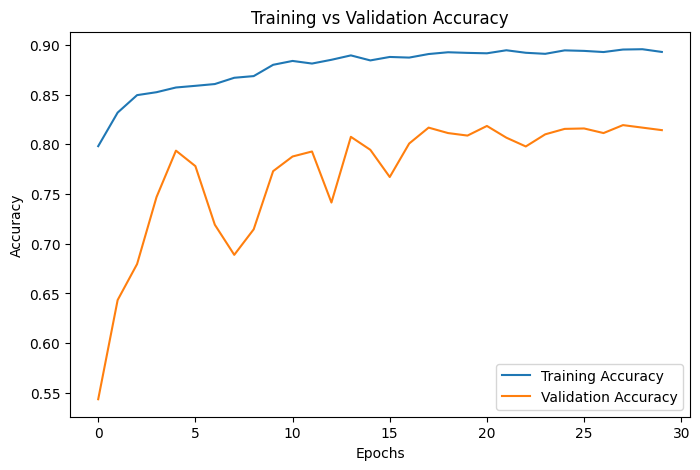

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

19. PLOT LOSS GRAPH

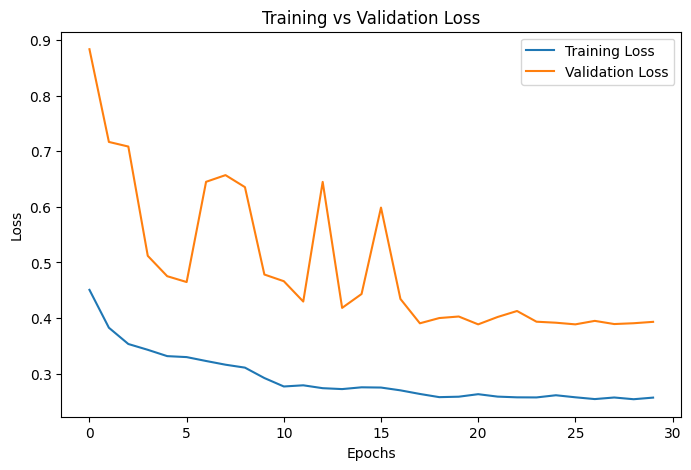

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

20. EVALUATE MODEL

In [20]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.9276 - loss: 0.1698
Test Accuracy: 0.8495000004768372


21. PREDICTIONS

In [21]:
predictions = model.predict(test_generator)

predicted_classes = (
    predictions > 0.5
).astype("int32").flatten()

true_classes = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step


22. CLASSIFICATION REPORT

In [22]:
print("Classification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes
    )
)

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.97      0.87      1000
           1       0.96      0.73      0.83      1000

    accuracy                           0.85      2000
   macro avg       0.87      0.85      0.85      2000
weighted avg       0.87      0.85      0.85      2000



23. CONFUSION MATRIX

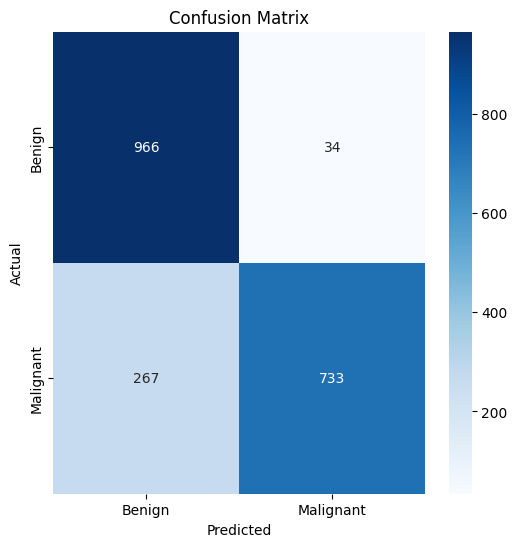

In [23]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=['Benign','Malignant'],

    yticklabels=['Benign','Malignant']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

24. LOAD SAVED MODEL

In [24]:
model = load_model("skin_cancer_cnn.h5")

25. PREDICTION SYSTEM

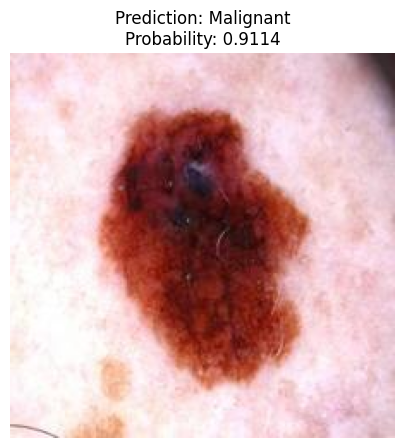

Image Path: /kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset/test/Malignant/6234.jpg
Prediction Score: 0.9114373
Predicted Class: Malignant


In [25]:
test_images = glob.glob(
    BASE_DIR + "/test/Malignant/*.jpg"
)

if len(test_images) == 0:

    print("No test images found.")

else:

    image_path = test_images[0]

    def predict_skin_cancer(image_path, model):

        img = image.load_img(
            image_path,
            target_size=(224,224)
        )

        img_array = image.img_to_array(img)

        img_array = img_array / 255.0

        img_array = np.expand_dims(
            img_array,
            axis=0
        )

        prediction = model.predict(
            img_array,
            verbose=0
        )[0][0]

        class_label = (
            "Malignant"
            if prediction > 0.5
            else "Benign"
        )

        plt.figure(figsize=(5,5))

        plt.imshow(img)

        plt.title(
            f"Prediction: {class_label}\nProbability: {prediction:.4f}"
        )

        plt.axis("off")

        plt.show()

        print("Image Path:", image_path)

        print("Prediction Score:", prediction)

        print("Predicted Class:", class_label)

    predict_skin_cancer(
        image_path,
        model
    )

In [26]:
model.save("/kaggle/working/skin_cancer_cnn.h5")

print("Model saved successfully")

Model saved successfully


In [27]:
import os

print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'skin_cancer_cnn.h5']


In [28]:
from IPython.display import FileLink

FileLink(r'skin_cancer_cnn.h5')

/kaggle/working/skin_cancer_cnn.h5

In [29]:
!du -h skin_cancer_cnn.h5

1.7M	skin_cancer_cnn.h5


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,363 (1.62 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)

In [31]:
from tensorflow.keras.models import load_model

model = load_model("skin_cancer_cnn.h5")

print("Model Loaded Successfully")

Model Loaded Successfully
